# 46 CodeChallenge: Manipulate Regression Slope

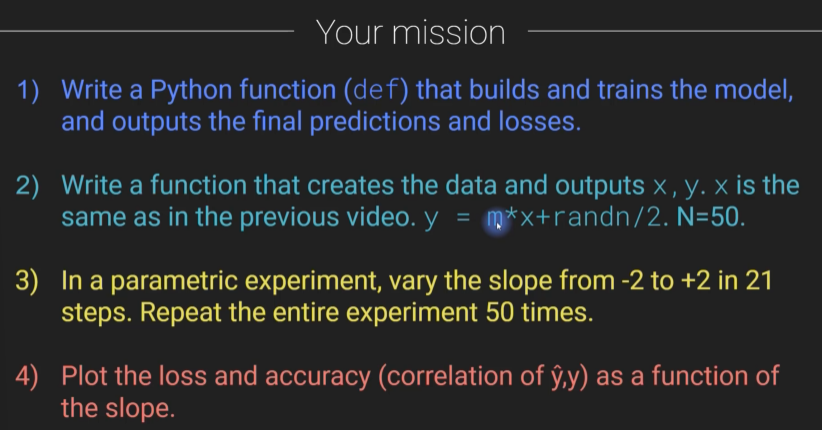

In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline

# set the backend for matplotlib
matplotlib_inline.backend_inline.set_matplotlib_formats('svg', 'png')

In [2]:
# import pytorch
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {device}")

using device: cuda


In [13]:
def data_fn(N=50, m=1, noise=0.5, device="cpu"):
    '''Generate synthetic data for linear regression'''
    x = torch.randn(N, 1, device=device)
    y = m * x + torch.randn(N, 1, device=device) * noise
    return x, y 

In [8]:
def model(x, y, lr = 0.01, epochs = 500, loss_fn = torch.nn.MSELoss()):
    '''The funcion trains a simple ANN regression model on the provided data (x, y) 
        and returns the predictions and losses.'''

    # Build a ANN regression model
    ANNreg = torch.nn.Sequential(
        torch.nn.Linear(1,1),
        torch.nn.ReLU(),
        torch.nn.Linear(1,1)
    ).to(device)
 
    # train the model

    # define optimizer
    optimizer = torch.optim.SGD(ANNreg.parameters(), lr=lr)

    # losses
    losses = torch.zeros(epochs, device=device)
       
    # training loop
    for epoch in range(epochs):
        # forward pass
        y_pred = ANNreg(x)

        # compute loss
        loss = loss_fn(y_pred, y)
        losses[epoch] = loss

        # backward pass (backpropagation)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    predictions = ANNreg(x)
    testloss = loss_fn(predictions, y)
    print(f"final loss: {testloss.item():.6f}")

    return predictions.detach(), losses.detach()  #, ANNreg 

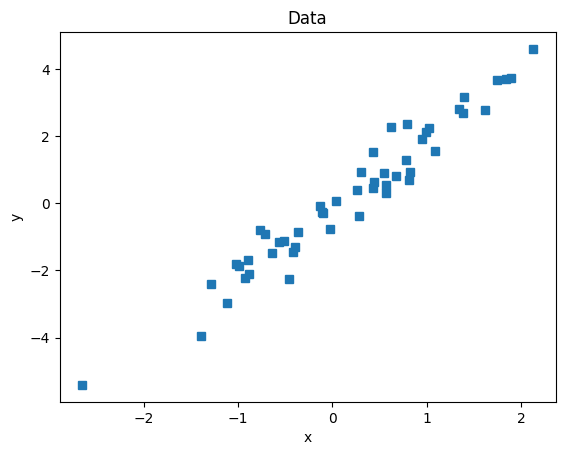

In [10]:
# create data 
x, y = data_fn(50, m=2, noise=0.5)

# plot data
plt.plot(x.cpu().numpy(), y.cpu().numpy(), 's')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data')
plt.show()

In [ ]:
# in a parametric experiment, vary the slope from -2 to +2 in 21 steps. Repeat the entire experiment 50 times
slopes = torch.linspace(-2, 2, 21, device=device)
all_losses = torch.zeros((len(slopes), 50), device=device)  # store losses for each slope and repetition
all_predictions = torch.zeros((len(slopes), 50, 50, 1), device=device)  # store predictions for each slope and repetition 
all_targets = torch.zeros((len(slopes), 50, 50, 1), device=device)

for i, m in enumerate(slopes):
    for j in range(50):
        x, y = data_fn(50, m=m.item(), noise=0.5, device=device)
        predictions, losses = model(x, y, lr=0.05, epochs=500)
        all_losses[i, j] = losses[-1]
        all_predictions[i, j] = predictions
        all_targets[i, j] = y


final loss: 0.333733
final loss: 3.329458
final loss: 0.260543
final loss: 0.278650
final loss: 0.258583
final loss: 0.234355
final loss: 0.265795
final loss: 4.105816
final loss: 0.180357
final loss: 0.267347
final loss: 0.285770
final loss: 3.551764
final loss: 0.200276
final loss: 0.265839
final loss: 4.723890
final loss: 0.245551
final loss: 0.314767
final loss: 0.199604
final loss: 0.367401
final loss: 0.176006
final loss: 0.182076
final loss: 0.197382
final loss: 0.190784
final loss: 0.178475
final loss: 0.291453
final loss: 0.294322
final loss: 0.256780
final loss: 0.212374
final loss: 4.371768
final loss: 0.357679
final loss: 3.653017
final loss: 0.194506
final loss: 0.375312
final loss: 0.164047
final loss: 4.875826
final loss: 0.248162
final loss: 0.256492
final loss: 4.749532
final loss: 0.202870
final loss: 3.401052
final loss: 0.346167
final loss: 0.262557
final loss: 0.258733
final loss: 4.253191
final loss: 0.307558
final loss: 4.148572
final loss: 0.257453
final loss: 4

In [15]:
# Plot the loss and accuracy (correlation of predictions and targets (y',y)) as a funciton of the slope (m) of the data.
# compute correlation between predictions and targets
correlations = torch.zeros(len(slopes), device=device)

for i in range(len(slopes)):
    preds = all_predictions[i].reshape(-1)
    targets = all_targets[i].reshape(-1)
    correlations[i] = torch.corrcoef(torch.stack((preds, targets)))[0, 1]

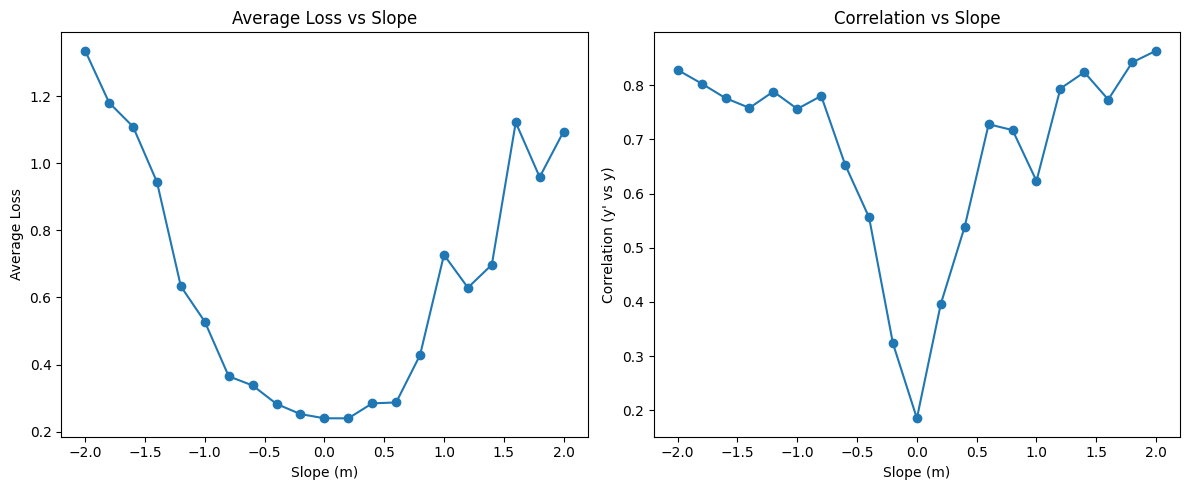

In [47]:
# plot losses
ax = plt.subplots(1, 2, figsize=(12, 5)) 
plt.subplot(1, 2, 1)
plt.plot(slopes.cpu().numpy(), all_losses.mean(dim=1).cpu().numpy(), 'o-')
plt.xlabel('Slope (m)')
plt.ylabel('Average Loss')
plt.title('Average Loss vs Slope')  
plt.subplot(1, 2, 2)

#  and correlations
plt.plot(slopes.cpu().numpy(), correlations.cpu().numpy(), 'o-')
plt.xlabel('Slope (m)')
plt.ylabel('Correlation (y\' vs y)')
plt.title('Correlation vs Slope')
plt.tight_layout()
plt.show()

